In [1]:
import numpy as np
import mujoco
import mujoco.viewer
import time
import matplotlib.pyplot as plt

#### 초기 설정 및 시각화할 엔드 이펙터 id 설정

In [2]:
xml_path = '/home/frlab/mj_opt/xmls/systems/universal_robots_ur5e/scene.xml'

model = mujoco.MjModel.from_xml_path(xml_path)
data = mujoco.MjData(model)

# 그리퍼의 파지점은 grasp_site, 6dof와 hand 연결부는 attachment_site
ee_site_name = "attachment_site"   # 또는 "attachment_site" 
ee_site_id = data.site(ee_site_name).id

#### 목표 waypoints 생성, 옵션은 원과 사각형

In [3]:
def generate_waypoints(init_site_pos, traj_type=''):

    if traj_type == 'rectangle':
        width = 0.15
        height = 0.15
       
        # Y-Z에 대한 사각형
        point1 = init_site_pos
        point2 = point1 + np.array([0.0, width, 0.0])
        point3 = point2 + np.array([0.0, 0.0, -height])
        point4 = point3 + np.array([0.0, -width, 0.0])
        point5 = point1

        return np.vstack((point1, point2, point3, point4, point5))

    
    elif traj_type == 'circle':
        radius = 0.15
        num_points = 30 

        center = init_site_pos - np.array([0.0, radius, 0.0])
        theta = np.linspace(0, 2 * np.pi, num_points)

        waypoints = np.zeros((num_points, 3))
        waypoints[:, 0] = init_site_pos[0]
        
        waypoints[:, 1] = center[1] + radius * np.cos(theta)
        waypoints[:, 2] = center[2] + radius * np.sin(theta)

        return waypoints
        

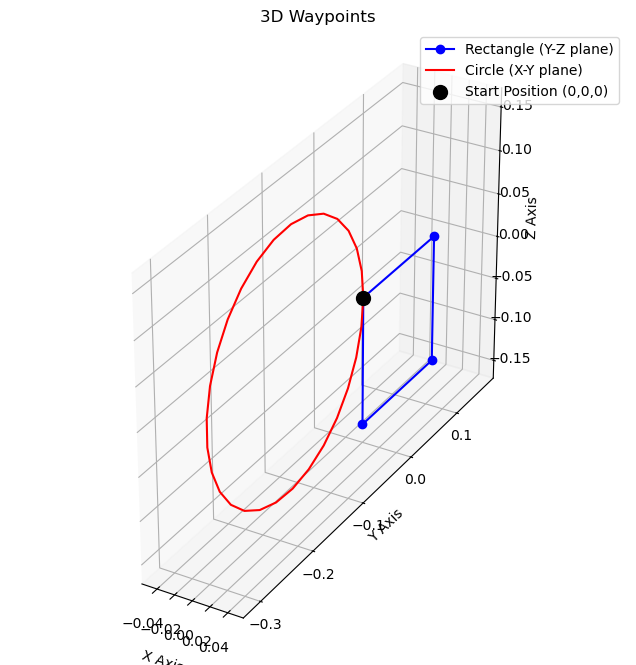

In [4]:
# 1. 초기 위치 설정 (x, y, z)
init_pos = [0.0, 0.0, 0.0]

# 2. 웨이포인트 데이터 생성
rect_waypoints = generate_waypoints(init_pos, traj_type='rectangle')
circle_waypoints = generate_waypoints(init_pos, traj_type='circle')

# 3. 3D 플롯 설정
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 4. 사각형 궤적 그리기 (파란색 선과 점)
ax.plot(rect_waypoints[:, 0], rect_waypoints[:, 1], rect_waypoints[:, 2], 
        label='Rectangle (Y-Z plane)', marker='o', color='blue', linestyle='-')

# 5. 원형 궤적 그리기 (빨간색 선)
ax.plot(circle_waypoints[:, 0], circle_waypoints[:, 1], circle_waypoints[:, 2], 
        label='Circle (X-Y plane)', color='red', linestyle='-')

# 6. 시작점 강조 표시
ax.scatter(init_pos[0], init_pos[1], init_pos[2], 
           color='black', s=100, label='Start Position (0,0,0)', zorder=5)

# 축 라벨 및 타이틀 설정
ax.set_xlabel('X Axis')
ax.set_ylabel('Y Axis')
ax.set_zlabel('Z Axis')
ax.set_title('3D Waypoints')

# X, Y, Z 축의 비율을 동일하게 맞춰서 형태가 찌그러지지 않게 함
ax.set_aspect('equal')

# 범례 표시 및 그리드
ax.legend()
plt.grid(True)

# 창 띄우기
plt.show()

#### waypoints 보간

In [5]:
def generate_task_space_trajectory(waypoints, seg_duration, dt=0.005):

    waypoints = np.array(waypoints)
    num_waypoints = len(waypoints)
    
    all_t, all_pos, all_vel, all_acc = [], [], [], []
    t_offset = 0.0
    
    # 1. 한 구간(Segment)에 대한 로컬 시간 배열 생성
    t_seg = np.arange(0, seg_duration, dt)
    
    # 2. 5차 다항식 (Quintic / Minimum Jerk) 시간에 따른 스케일링 비율 계산
    # s는 0에서 1로 변하는 위치 비율, s_vel과 s_acc는 그 미분값
    T = seg_duration
    s = t_seg / T
    s_pos = 10 * s**3 - 15 * s**4 + 6 * s**5
    s_vel = (30 * s**2 - 60 * s**3 + 30 * s**4) / T
    s_acc = (60 * s - 180 * s**2 + 120 * s**3) / (T**2)
    
    # 3. 각 구간(Edge)마다 공간 벡터(dp)에 시간 스케일링을 곱하여 궤적 생성
    for k in range(num_waypoints - 1):
        p0 = waypoints[k]      # 출발점
        p1 = waypoints[k+1]    # 도착점
        dp = p1 - p0           # 이동해야 할 공간 벡터 (3차원)
        
        # np.outer를 사용해 (시간 배열길이 x 3차원) 크기의 궤적 행렬을 한 번에 생성
        pos_seg = p0 + np.outer(s_pos, dp)
        vel_seg = np.outer(s_vel, dp)
        acc_seg = np.outer(s_acc, dp)
        
        all_t.append(t_seg + t_offset)
        all_pos.append(pos_seg)
        all_vel.append(vel_seg)
        all_acc.append(acc_seg)
        
        t_offset += T # 다음 구간을 위해 시간 오프셋 누적
        
    # 리스트들을 1차원(혹은 2차원) NumPy 배열로 병합
    return (np.concatenate(all_t), 
            np.concatenate(all_pos), 
            np.concatenate(all_vel), 
            np.concatenate(all_acc))

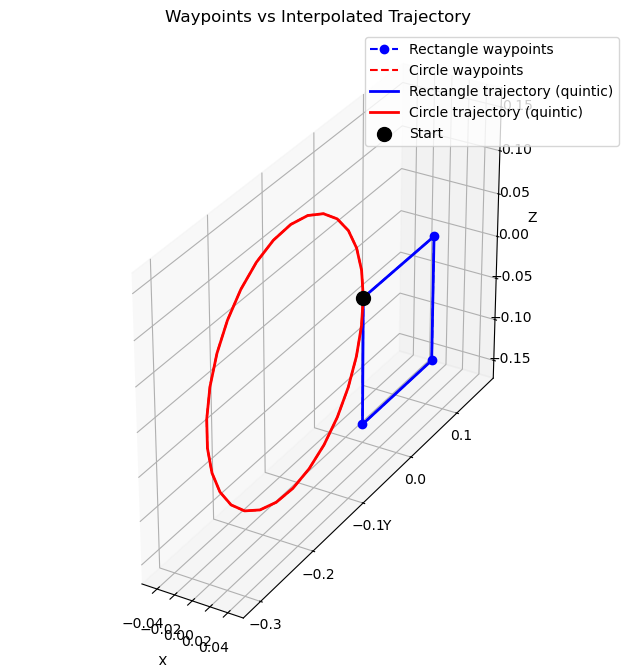

In [6]:
init_pos = np.array([0.0, 0.0, 0.0])
seg_duration = 2.0
dt = 0.005

rect_waypoints   = generate_waypoints(init_pos, traj_type='rectangle')
circle_waypoints = generate_waypoints(init_pos, traj_type='circle')

_, rect_pos,   _, _ = generate_task_space_trajectory(rect_waypoints,   seg_duration, dt)
_, circle_pos, _, _ = generate_task_space_trajectory(circle_waypoints, seg_duration, dt)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 웨이포인트 (원본, 점선)
ax.plot(rect_waypoints[:, 0], rect_waypoints[:, 1], rect_waypoints[:, 2],
        'b--o', label='Rectangle waypoints')
ax.plot(circle_waypoints[:, 0], circle_waypoints[:, 1], circle_waypoints[:, 2],
        'r--', label='Circle waypoints')

# 보간 궤적 (실선)
ax.plot(rect_pos[:, 0], rect_pos[:, 1], rect_pos[:, 2],
        'b-', linewidth=2, label='Rectangle trajectory (quintic)')
ax.plot(circle_pos[:, 0], circle_pos[:, 1], circle_pos[:, 2],
        'r-', linewidth=2, label='Circle trajectory (quintic)')

ax.scatter(*init_pos, color='black', s=100, label='Start', zorder=5)
ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.set_title('Waypoints vs Interpolated Trajectory')
ax.set_aspect('equal')
ax.legend()
plt.show()



#### 엔드 이펙터의 선속도와 각속도를 가져옴 이때 Geom랑 Site 함수 각각 만듬

In [7]:
def get_geom_velocity(model, data, geom_name):

    geom_vel = np.zeros(6)
    geom_type = mujoco.mjtObj.mjOBJ_GEOM
    geom_id = data.geom(geom_name).id
    
    # 물리엔진에서 해당 Geom의 현재 속도를 계산해 덮어씀
    mujoco.mj_objectVelocity(model, data, geom_type, geom_id, geom_vel, 0)

    # 6차원 벡터의 크기만 계산해 반환
    return np.linalg.norm(geom_vel)

In [8]:
def get_site_velocity(model, data, site_name):

    site_vel = np.zeros(6)
    site_type = mujoco.mjtObj.mjOBJ_SITE
    site_id = data.site(site_name).id
    
    mujoco.mj_objectVelocity(model, data, site_type, site_id, site_vel, 0)

    return np.linalg.norm(site_vel)

#### 시각용 캡슐을 Scene에 추가

In [9]:
def add_visual_trajectory(scene, waypoints, radius, rgba):
    for i in range(len(waypoints) - 1):
        if scene.ngeom >= scene.maxgeom:
            break
        point1 = waypoints[i]
        point2 = waypoints[i + 1]
        mujoco.mjv_initGeom(scene.geoms[scene.ngeom],
                            mujoco.mjtGeom.mjGEOM_CAPSULE, np.zeros(3),
                            np.zeros(3), np.zeros(9), rgba.astype(np.float32))
        mujoco.mjv_connector(scene.geoms[scene.ngeom],
                             mujoco.mjtGeom.mjGEOM_CAPSULE, radius,
                             point1, point2)
        scene.ngeom += 1

In [10]:
def modify_scene(scn):
    if len(actual_position) > 1:
        for i in range(len(actual_position) - 1):
            if scn.ngeom >= scn.maxgeom:
                break
            mujoco.mjv_initGeom(scn.geoms[scn.ngeom],
                                mujoco.mjtGeom.mjGEOM_CAPSULE, np.zeros(3),
                                np.zeros(3), np.zeros(9),
                                np.array([1, 0, 0, 0.5], dtype=np.float32))
            mujoco.mjv_connector(scn.geoms[scn.ngeom],
                                 mujoco.mjtGeom.mjGEOM_CAPSULE, 0.003,
                                 actual_position[i], actual_position[i + 1])
            scn.ngeom += 1

#### 궤적 저장할 배열들

In [11]:
times = []
error_pos_x = []
error_pos_z = []
error_pos_y = []

desired_position = []
actual_position = []
actual_velocity = []

pos_error = []
ori_error = []

#### 저장된 위치/속도 데이터를 바탕으로 과거의 궤적을 그림

#### 기타 설정

In [12]:
# ── DLS IK 파라미터 (diffik.py 참고) ──────────────────────────────────
integration_dt = 1.0
damping        = 1e-3
max_angvel     = 0.5

# ── UR5 조인트 / 액추에이터 설정 ──────────────────────────────────────
joint_names    = ['shoulder_pan_joint', 'shoulder_lift_joint', 'elbow_joint',
                  'wrist_1_joint', 'wrist_2_joint', 'wrist_3_joint']
actuator_names = ['shoulder_pan', 'shoulder_lift', 'elbow',
                  'wrist_1', 'wrist_2', 'wrist_3']

joint_ids    = np.array([model.joint(name).id  for name in joint_names])
dof_ids      = np.array([model.jnt_dofadr[jid]  for jid in joint_ids])   # nv 기준
qpos_ids     = np.array([model.jnt_qposadr[jid] for jid in joint_ids])   # qpos 기준
actuator_ids = np.array([model.actuator(name).id for name in actuator_names])

#### 시뮬레이션 초기화

In [13]:
# ── 초기화 및 궤적 생성 ───────────────────────────────────────────────
key_id = model.key('home').id
mujoco.mj_resetDataKeyframe(model, data, key_id)
mujoco.mj_forward(model, data)

init_ee_pos  = data.site(ee_site_id).xpos.copy()
seg_duration = 2.0
traj_dt      = model.opt.timestep
duration = 1000

waypoints = generate_waypoints(init_ee_pos, traj_type='circle')
traj_t, traj_pos, traj_vel, traj_acc = generate_task_space_trajectory(
    waypoints, seg_duration, traj_dt)
traj_len = len(traj_t)

# ── 사전 할당 ─────────────────────────────────────────────────────────
jac   = np.zeros((6, model.nv))
diag  = damping * np.eye(6)
error = np.zeros(6)

target_quat    = np.zeros(4)
site_quat      = np.zeros(4)
site_quat_conj = np.zeros(4)
error_quat     = np.zeros(4)
mujoco.mju_mat2Quat(target_quat, data.site(ee_site_id).xmat)  # 초기 자세 저장

#### 시뮬레이션 루프

In [14]:
# ── 주기 설정 ─────────────────────────────────────────────────────────
# 랜더링
render_fps = 60
render_dt = 1.0 / render_fps
next_render_time = data.time + render_dt

# 제어
ctrl_rate = 100 # Hz
ctrl_dt = 1.0 / ctrl_rate
next_ctrl_time = data.time

# ── 시뮬레이션 루프 ───────────────────────────────────────────────────
with mujoco.viewer.launch_passive(model, data,
                                  show_left_ui=False, show_right_ui=False) as viewer:

    add_visual_trajectory(viewer.user_scn, waypoints, 0.002,
                          np.array([0., 1., 0., 0.8]))
    for wp in waypoints:
        if viewer.user_scn.ngeom >= viewer.user_scn.maxgeom:
            break
        mujoco.mjv_initGeom(viewer.user_scn.geoms[viewer.user_scn.ngeom],
                            mujoco.mjtGeom.mjGEOM_SPHERE,
                            np.array([0.008, 0., 0.]),
                            wp, np.eye(3).flatten(),
                            np.array([0., 1., 0., 1.], dtype=np.float32))
        viewer.user_scn.ngeom += 1
    ngeom_base = viewer.user_scn.ngeom

    while viewer.is_running() and data.time < duration:

        # 1. 뷰어 창을 닫으면 즉시 종료
        if not viewer.is_running():
            break
            
        # 2. 제어 루프
        if data.time >= next_ctrl_time:

            traj_idx   = int(data.time / traj_dt) % traj_len
            target_pos = traj_pos[traj_idx]

            # position error
            error[:3] = target_pos - data.site(ee_site_id).xpos

            # orientation error (초기 자세 유지)
            mujoco.mju_mat2Quat(site_quat, data.site(ee_site_id).xmat)
            mujoco.mju_negQuat(site_quat_conj, site_quat)
            mujoco.mju_mulQuat(error_quat, target_quat, site_quat_conj)
            mujoco.mju_quat2Vel(error[3:], error_quat, 1.0)

            # Jacobian
            mujoco.mj_jacSite(model, data, jac[:3], jac[3:], ee_site_id)

            # DLS IK
            dq = jac.T @ np.linalg.solve(jac @ jac.T + diag, error)

            dq_abs_max = np.abs(dq[dof_ids]).max()
            if max_angvel > 0 and dq_abs_max > max_angvel:
                dq *= max_angvel / dq_abs_max

            q = data.qpos.copy()
            mujoco.mj_integratePos(model, q, dq, integration_dt)
            q[qpos_ids] = np.clip(q[qpos_ids],
                                   model.jnt_range[joint_ids, 0],
                                   model.jnt_range[joint_ids, 1])
            data.ctrl[actuator_ids] = q[qpos_ids]
            
            next_ctrl_time += ctrl_dt

        data.qfrc_applied[0:7] = data.qfrc_bias[0:7]

        mujoco.mj_step(model, data)

        ee_pos_now = data.site(ee_site_id).xpos.copy()
        actual_position.append(ee_pos_now)
        actual_velocity.append(get_site_velocity(model, data, ee_site_name))
        desired_position.append(target_pos.copy())
        error_pos_x.append(target_pos[0] - ee_pos_now[0])
        error_pos_z.append(target_pos[2] - ee_pos_now[2])
        error_pos_y.append(target_pos[1] - ee_pos_now[1])
        times.append(data.time)

        # 3. 60hz 랜더링 루프
        if data.time >= next_render_time:
            viewer.user_scn.ngeom = ngeom_base
            modify_scene(viewer.user_scn)
            viewer.sync()
            next_render_time += render_dt


#### Y, Z 오차 시각화

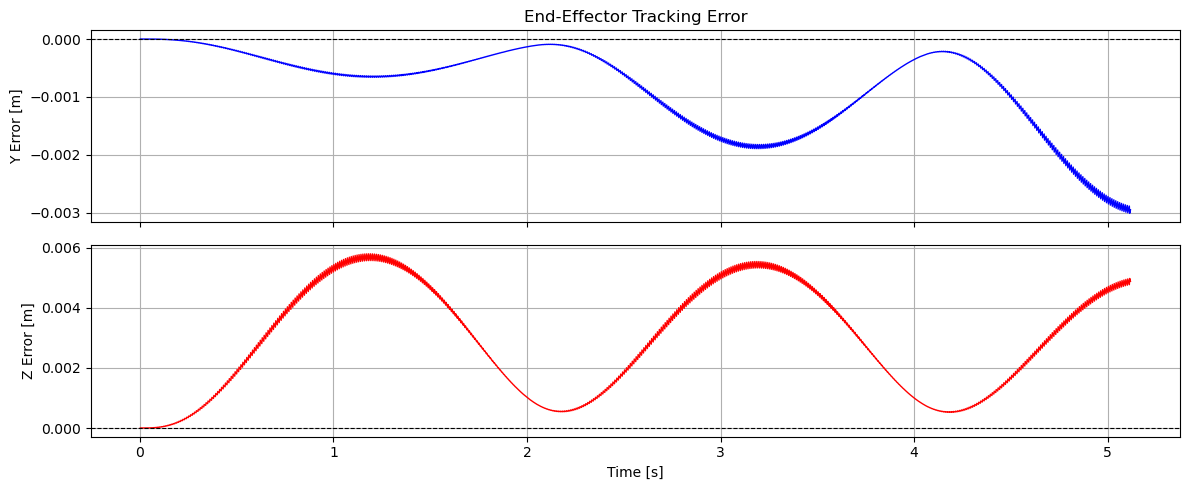

In [15]:
# 7. X, Y, Z 오차 시각화
desired_position_arr = np.array(desired_position)
actual_position_arr  = np.array(actual_position)

fig, (ax1, ax3) = plt.subplots(2, 1, figsize=(12, 5), sharex=True)

ax1.plot(times, error_pos_y, 'b-', linewidth=1)
ax1.axhline(0, color='k', linestyle='--', linewidth=0.8)
ax1.set_ylabel('Y Error [m]')
ax1.set_title('End-Effector Tracking Error')
ax1.grid(True)
'''
ax2.plot(times, error_pos_y, 'r-', linewidth=1)
ax2.axhline(0, color='k', linestyle='--', linewidth=0.8)
ax2.set_ylabel('Z Error [m]')
ax2.set_xlabel('Time [s]')
ax2.grid(True)
'''
ax3.plot(times, error_pos_z, 'r-', linewidth=1)
ax3.axhline(0, color='k', linestyle='--', linewidth=0.8)
ax3.set_ylabel('Z Error [m]')
ax3.set_xlabel('Time [s]')
ax3.grid(True)

plt.tight_layout()
plt.show()